Here we conclude the uncertainty quantification procedure with Jezebel by performing the necessary post-processing of data. Very little of what's presented in this notebooks is WINDIGO functionality, but post-processing capabilities are anticipated for future releases for WINDIGO.

In [1]:
#Import modules
import numpy as np 
import matplotlib.pyplot as plt
import os
import openmc
import WINDIGO

#Set NJOY path
os.environ["NJOY"] = "/home/jacob/miniconda3/envs/openmc-env/bin/njoy"

We first need to extract the k_eff values and their associated uncertainties from our simulation results.

In [4]:
#Cd into the examples folder

os.chdir('examples')

#Retrieve the base keff results

base_keff = []
base_keff_error = []

sp = openmc.StatePoint('BaseModelFolder/statepoint.1000.h5')

extracted_keff = sp.keff.nominal_value 
extracted_keff_error = sp.keff.std_dev

base_keff.append(extracted_keff)
base_keff_error.append(extracted_keff_error)

np.save('Jezebel_BaseKeff_Value.npy', base_keff)
np.save('Jezebel_BaseKeff_Error.npy', base_keff_error)

In [5]:
#Retrieve the direct perturbation results
#Need to retrieve these in order of increasing energy to ensure the sensitivity plots
#and uncertainty quantification is performed properly
direct_perturbed_keffs = []
direct_perturbed_keff_errors = []

for ii in range(1,45):
    sp = openmc.StatePoint(f"Jezebel_Pu239_DirectPerturbedModels/Model_{ii}_Folder/statepoint.1000.h5")

    extracted_keff = sp.keff.nominal_value 
    extracted_keff_error = sp.keff.std_dev

    direct_perturbed_keffs.append(extracted_keff)
    direct_perturbed_keff_errors.append(extracted_keff_error)  

np.save('Jezebel_DirectKeff_Values.npy', direct_perturbed_keffs)
np.save('Jezebel_DirectKeff_Errors.npy', direct_perturbed_keff_errors)

#Retrieve the random sampling results
#These don't need to be retrieved in any particular order so long as they are all gathered
random_sampling_keffs = []
random_sampling_keff_errors = []

for ii in range(1,101):
    sp = openmc.StatePoint(f"Jezebel_Pu239_RandomPerturbedModels/Model_{ii}_Folder/statepoint.1000.h5")

    extracted_keff = sp.keff.nominal_value 
    extracted_keff_error = sp.keff.std_dev

    random_sampling_keffs.append(extracted_keff)
    random_sampling_keff_errors.append(extracted_keff_error)  

np.save('Jezebel_RandomKeff_Values.npy', random_sampling_keffs)
np.save('Jezebel_RandomKeff_Errors.npy', random_sampling_keff_errors)


We need to retrieve the absolute covariance matrix for Pu-239's fission cross section since we did not do so previously.


 njoy 2016.78  03Feb25                                       04/07/26 12:36:09
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.3s

 ---message from rdf2bw---calculation of angular distribution not installed.

 broadr...                                                                0.8s

 thermr...                                                                0.9s

 wrote thermal data for temp = 3.0000E+02                                 0.9s

 heatr...                                                                 0.9s

 ---message from hinit---mf6, mt 16 does not give recoil za= 94238
                          one-particle recoil approx. used.

 ---message from hinit---mf6, mt 17 does not give recoil za= 94237
                          one-particle recoil approx. used.

 ---message from hinit---m

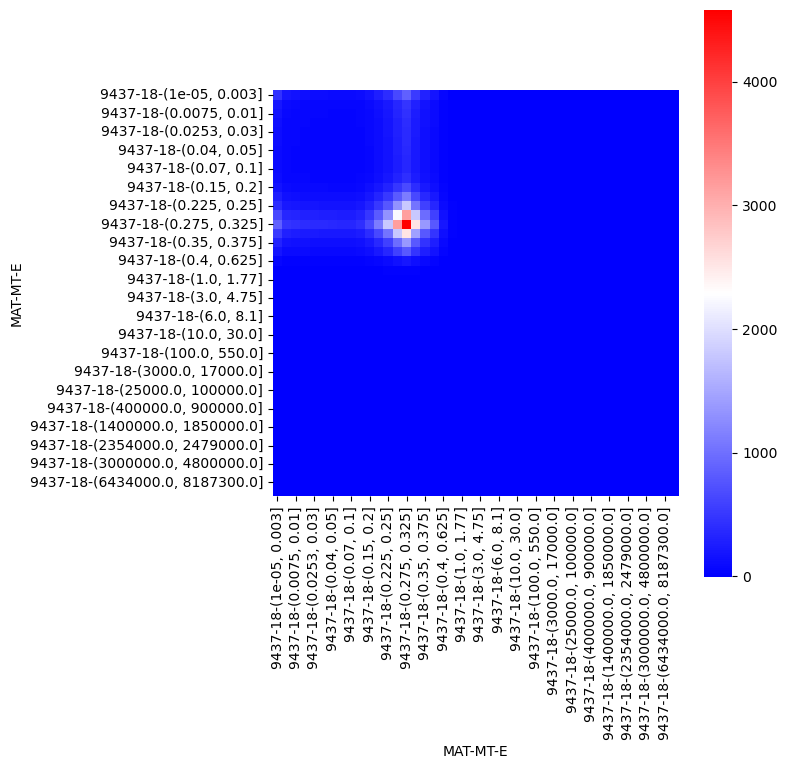

In [6]:
#Input SCALE44 energy grid
scale44_grid_MeV = np.array([1.0000E-11, 3.0000E-9, 7.5000E-9, 1.0000E-8, 2.5300E-8,
                             3.0000E-8, 4.0000E-8, 5.0000E-8, 7.0000E-8, 1.0000E-7,
                             1.5000E-7, 2.0000E-7, 2.2500E-7, 2.5000E-7, 2.7500E-7,
                             3.2500E-7, 3.5000E-7, 3.7500E-7, 4.0000E-7, 6.2500E-7, 
                             1.0000E-6, 1.7700E-6, 3.0000E-6, 4.7500E-6, 6.0000E-6,
                             8.1000E-6, 1.0000E-5, 3.0000E-5, 1.0000E-4, 5.5000E-4,
                             3.0000E-3, 1.7000E-2, 2.5000E-2, 1.0000E-1, 4.0000E-1,
                             9.0000E-1, 1.4000E0, 1.8500E0, 2.3540E0, 2.4790E0,
                             3.0000E0, 4.8000E0, 6.4340E0, 8.1873E0, 2.0000E1])

#Convert to eV
scale44_grid_eV = scale44_grid_MeV * 10**6

#Retrieve covariance data
pu239_fission_absolute_covariance_data_path, pu239_fission_absolute_covariance_plot_path = WINDIGO.sandy_covariance_retrieval(
    energy_grid=scale44_grid_eV,
    nuclide="Pu239",
    mt_Number=18,
    data_library="endfb_80",
    temperature=300,
    relative_Flag=False,
    plotting_Flag=True
)

The last set of data we need to perform the uncertainty quantification is to retrieve the values of the unperturbed and perturbed Pu-239 fission cross section at the midpoint energies for the SCALE44 energy grid. While not needed for the random sampling scheme, they are needed for the direct perturbation.

In [ ]:
#Retrieve the SCALE44 midpoint energies
energy_midpoints = []

for ii in range(0, len(scale44_grid_eV) -1):
    
    current_midpoint = (scale44_grid_eV[ii] + scale44_grid_eV[ii+1])/2

    energy_midpoints.append(current_midpoint)

#Retrieve the original and modified xs data
#Original Cross Sections
original_xs = []

#Since OpenMC's pre-generated libraries doesn't include cross section data at 300K, we will use the code's interfacing with
#NJOY to produce cross section data at this temperature
original_xs_data = openmc.data.IncidentNeutron.from_njoy('/mnt/c/Users/jacob/frendy_20241030/ENDF-B-VIII.0/ENDF-B-VIII.0/neutrons/n-094_Pu_239.endf', 
                                                         temperatures = [300,])

for ii in range(0, 44):
    
    fission_data = original_xs_data[18]

    desired_xs = fission_data.xs['300K'](energy_midpoints[ii])

    original_xs.append(desired_xs)

original_xs = np.array(original_xs)

#Pertrubed Cross Sections
perturbed_xs = []

for ii in range(0, 44):
    if ii < 9:
        perturbed_filename = f"/mnt/c/Users/jacob/frendy_20241030/Pu239_DirectPerturbationACEFiles_ReactionMT_18/000{ii+1}/Pu239_upgrade.ace_000{ii+1}.h5"
    else:
        perturbed_filename = f"/mnt/c/Users/jacob/frendy_20241030/Pu239_DirectPerturbationACEFiles_ReactionMT_18/00{ii+1}/Pu239_upgrade.ace_00{ii+1}.h5"

    perturbed_data = openmc.data.IncidentNeutron.from_hdf5(perturbed_filename)

    perturbed_fission_data = perturbed_data[18]

    desired_perturbed_xs = perturbed_fission_data.xs['300K'](energy_midpoints[ii])

    perturbed_xs.append(desired_perturbed_xs)

perturbed_xs = np.array(perturbed_xs)

np.save('Original_Pu239Fission_xs.npy', original_xs)
np.save('Perturbed_Pu239Fission_xs.npy', perturbed_xs)

#Print the percent difference between the perturbed and original cross sections to
#check if perturbations were performed approximately correctly
print('Direct Perturbation Percent Differences: \n')
print((perturbed_xs-original_xs)/original_xs * 100)

Throughout the course of research by the creators of WINDIGO using FRENDY, it has been observed that FRENDY doesn't appear to always perform desired perturbations perfectly across the energy intervals of interest. Users of WINDIGO should keep this in mind when utilizing FRENDY to perform perturbations. Investigations into possible improvements to FRENDY input files to rectify this is a current topic of research for the WINDIGO development team.

We can now perform our analysis. We will first calculate the direct perturbation uncertainty.

In [8]:
#Load covariance data
cov_matrix = np.loadtxt(open(pu239_fission_absolute_covariance_data_path, 'rb'), delimiter = ',')

direct_perturbed_keffs = np.array(direct_perturbed_keffs)

#Calculate the absolute sensitivity coefficients
absolute_sens_coefficients = (direct_perturbed_keffs - base_keff) / (perturbed_xs - original_xs)

#Calculate the variance via the Sandwich Rule, and use it to get the uncertainty/standard deviation
variance = absolute_sens_coefficients @ cov_matrix @ absolute_sens_coefficients.T

std_dev = np.sqrt(variance)

print('Direct Perturbation Uncertainty: ' + str(std_dev*10**5) + ' pcm')

Direct Perturbation Uncertainty: 889.1112536845961 pcm


Now we will calculate the random sampling uncertainty.

In [9]:
#Calculate the number of perturbed keffs
n = len(random_sampling_keffs)

random_sampling_keffs = np.array(random_sampling_keffs)

#Calculate the mean of the keff values
mean_keff = np.mean(random_sampling_keffs)

#Find the squared distances between the perturbed keffs and the mean keff
squared_distances = (random_sampling_keffs - mean_keff)**2

#Take the mean of the squared distances, and use it to find the standard deviation
sample_variance = np.sum(squared_distances)/(n-1)

sample_std_dev = np.sqrt(sample_variance)

print('Random Sampling Uncertainty: ' + str(sample_std_dev*10**5) + ' pcm')

Random Sampling Uncertainty: 882.5802303004044 pcm


Although not needed to quantify the uncertainty, we can use the data we have gathered to create sensitivity plots for more qualitative insights.

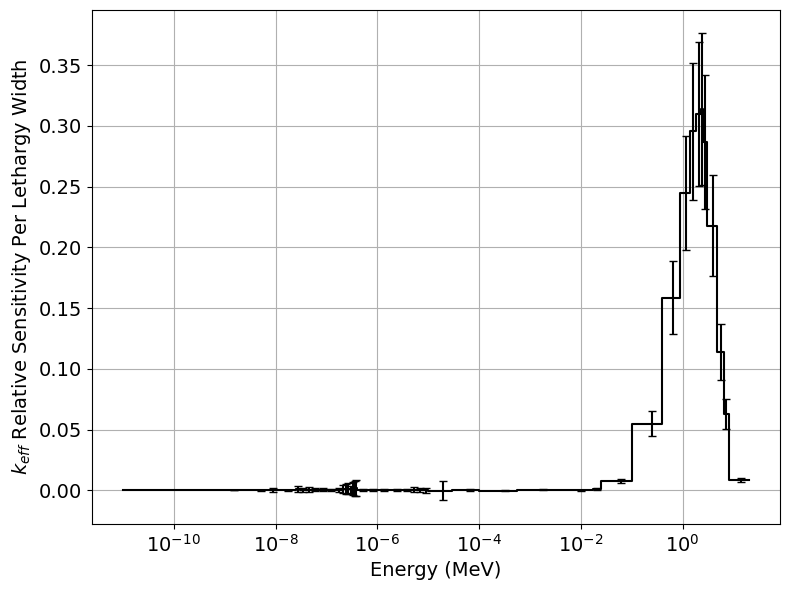

In [11]:
#Convert the energy midpoints to MeV
energy_midpoints_MeV = np.array(energy_midpoints) /(10**6)

#Convert all required data to Numpy arrays
base_keff = np.array(base_keff)
base_keff_error = np.array(base_keff_error)
direct_perturbed_keffs = np.array(direct_perturbed_keffs)
direct_perturbed_keff_errors = np.array(direct_perturbed_keff_errors)

#Compute the relative sensitivity coefficients
relative_sens_coefficients = (direct_perturbed_keffs - base_keff)/(perturbed_xs - original_xs) * (original_xs/base_keff)

#Retrieve the cross section uncertainties 
xs_squared_errors = []
for ii in range(0, len(cov_matrix[0])):
    xs_squared_errors.append(cov_matrix[ii, ii])
xs_squared_errors = np.array(xs_squared_errors)

#Compute errors using first order error propogation
relative_sens_error_term1 = (original_xs/(base_keff*(perturbed_xs - original_xs)))**2 * direct_perturbed_keff_errors**2
relative_sens_error_term2 = ((-1*direct_perturbed_keffs*original_xs)/(base_keff**2 * (perturbed_xs - original_xs)))**2 * base_keff_error**2
relative_sens_error_term3 = (original_xs * (base_keff - direct_perturbed_keffs)/(base_keff * (perturbed_xs - original_xs)**2))**2 * xs_squared_errors
relative_sens_error_term4 = (perturbed_xs * (direct_perturbed_keffs - base_keff)/(base_keff * (perturbed_xs - original_xs)**2))**2 * xs_squared_errors

relative_sens_error = np.sqrt(relative_sens_error_term1 + relative_sens_error_term2 + relative_sens_error_term3 + relative_sens_error_term4)

#Find the lethargy widths
lethargy_widths = []

for ii in range(0, len(scale44_grid_MeV)-1):
    lethargy_width = np.log(scale44_grid_MeV[ii+1] / scale44_grid_MeV[ii])
    lethargy_widths.append(lethargy_width)

#Divide the sensitivity coefficients by the lethargy widths
relative_sens_per_lethargy = relative_sens_coefficients/lethargy_widths

#Add a 0 to the sensitivities per lethargy for the sake of plotting
#Needed to help the histogram plotting work properly
relative_sens_per_lethargy = np.insert(relative_sens_per_lethargy, 0,0)

#Divide the relative sensitivity errors by the lethargy bins
relative_sens_per_lethargy_error = relative_sens_error/lethargy_widths

#Add zeros to the error array and energy midpoint array to help with plotting
relative_sens_per_lethargy_error = np.insert(relative_sens_per_lethargy_error, 0,0)

energy_midpoints_insert = np.insert(energy_midpoints_MeV, 0, 0)

#Plot the relative sensitivity per unit lethargy
fig, ax = plt.subplots(figsize = (8,6))

ax.step(scale44_grid_MeV, relative_sens_per_lethargy, color = 'black')
ax.errorbar(energy_midpoints_insert, relative_sens_per_lethargy, yerr = relative_sens_per_lethargy_error, fmt = 'none', color = 'black', capsize = 3)

ax.tick_params(axis = 'x', labelsize = 14)
ax.tick_params(axis = 'y', labelsize = 14)

ax.set_xscale('log')
ax.set_xlabel('Energy (MeV)', fontsize = 14)
ax.set_ylabel('$k_{eff}$ Relative Sensitivity Per Lethargy Width', fontsize = 14)
ax.grid()

plt.tight_layout()
plt.show()

This concludes the set of notebooks dedicated to using Jezebel as an example of the uncertainty quantification procedure.